In [39]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy.io import loadmat
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
# the following import is required for matplotlib < 3.2:
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_rel
from scipy.signal import butter, filtfilt
import mne
import re
import imp
import ast
import matplotlib
import funcs
imp.reload(funcs)

from scipy import signal
from scipy.signal import resample
from scipy.ndimage import zoom

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [40]:
load_path = os.path.join('..', '..', '..', 'data', 'subjects_behavior_fooof.pkl')
fooof_table = pd.read_pickle(load_path)

exp_info = funcs.load_info() # higher level exp younger/higher cortical excitatory
rpm_answers = funcs.load_rpm_answers()
subjects_behavior = funcs.load_subjects_behavior()

rpm_difficulty = pd.DataFrame(columns=['question', 'average time', 'difficulty'])
rpm_difficulty['question'] = rpm_answers['question'][0:82]
df = subjects_behavior[(subjects_behavior['reaction time'] != 0) & (subjects_behavior['task time'] == 'pre')]
for i in range(82):
    question_index = rpm_difficulty['question'][i]
    rts = df[df['question'] == question_index]['reaction time']
    rpm_difficulty['average time'][i] = rts.mean()
    
conditions = [
    (rpm_difficulty['average time'] < 10),
    (rpm_difficulty['average time'] >= 10) & (rpm_difficulty['average time'] <= 20),
    (rpm_difficulty['average time'] > 20)
]
choices = [1, 2, 3]
rpm_difficulty['difficulty'] = np.select(conditions, choices)
# rpm_difficulty

c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subjects_behavior = pd.concat([subjects_behavior, one_behavior], ignore_index=True)
C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_16276\366848068.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typ

### Adjacency

Opening raw data file ..\..\..\data\26\raw_26_1.fif...
    Read a total of 1 projection items:
        EOG-eeg--0.200-0.200-PCA-01 (1 x 31) active
    Range : 0 ... 5567282 =      0.000 ...  1159.850 secs
Ready.
Reading 0 ... 5567282  =      0.000 ...  1159.850 secs...


C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_16276\3396508048.py:49: RuntimeWarning: This filename (..\..\..\data\26\raw_26_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_path, preload=True)


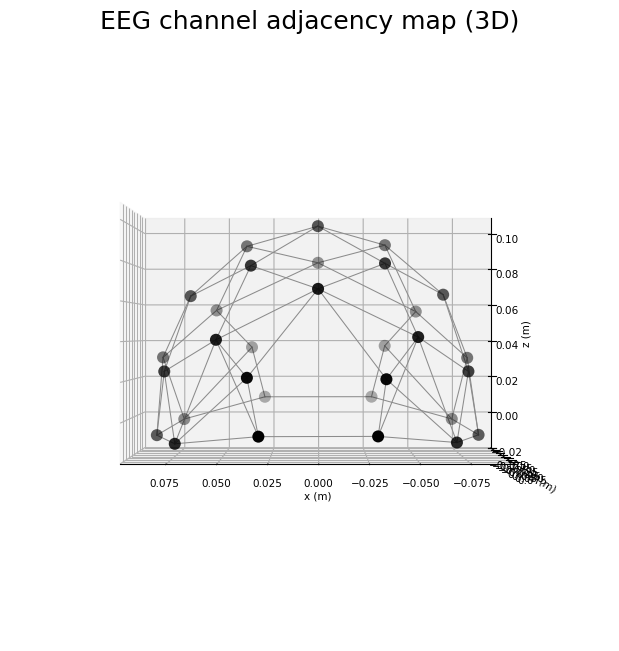

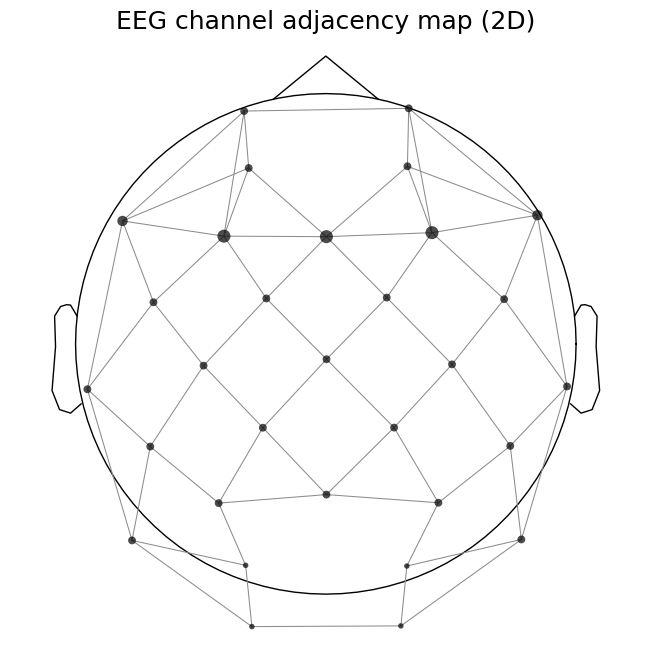

In [41]:
from scipy.sparse import csr_matrix, csr_array
from scipy.spatial import distance_matrix

def compute_adjacency():
    eeg_data = np.zeros((31, 2))
    # get placement data of standard 10-20 system
    montage_1020 = mne.channels.make_standard_montage('standard_1020')
    positions_1020 = montage_1020._get_ch_pos()
    ch_names = ['Fp1', 'Fp2', 
                'AF3', 'AF4', 
                'F7', 'F3', 'Fz', 'F4', 'F8',
                'FC5', 'FC1', 'FC2', 'FC6',
                'T7', 'C3', 'Cz', 'C4', 'T8',
                'CP5', 'CP1', 'CP2', 'CP6',
                'P7', 'P3', 'Pz', 'P4', 'P8',
                'PO3', 'PO4',
                'O1', 'O2']
    ch_types = ['eeg'] * 31
    info = mne.create_info(ch_names, sfreq=4800, ch_types=ch_types, verbose=False)
    raw = mne.io.RawArray(eeg_data, info, verbose=False)

    elec_coords = {ch: positions_1020[ch] for ch in ch_names}
    montage = mne.channels.make_dig_montage(elec_coords, coord_frame='head')
    raw.set_montage(montage)
    
    # Extract the 3D coordinates
    pos = np.stack([raw.info['dig'][i]['r'] for i in range(len(raw.info['dig'])) if raw.info['dig'][i]['kind'] == mne.io.constants.FIFF.FIFFV_POINT_EEG])
    
    # Calculate the distance matrix
    dist_matrix = distance_matrix(pos, pos)
    
    # Define adjacency based on distance threshold
    threshold = np.percentile(dist_matrix, 16.5)  # !!!!! 17.5th percentile of distances as threshold
    adjacency_matrix = dist_matrix < threshold
    
    return adjacency_matrix


ch_names = ['Fp1', 'Fp2', 
            'AF3', 'AF4', 
            'F7', 'F3', 'Fz', 'F4', 'F8',
            'FC5', 'FC1', 'FC2', 'FC6',
            'T7', 'C3', 'Cz', 'C4', 'T8',
            'CP5', 'CP1', 'CP2', 'CP6',
            'P7', 'P3', 'Pz', 'P4', 'P8',
            'PO3', 'PO4',
            'O1', 'O2']
raw_path = os.path.join('..', '..', '..', 'data', str(26), 'raw_' + str(26) + '_' + str(1) + '.fif')
raw = mne.io.read_raw_fif(raw_path, preload=True)
adjacency_ndarray = compute_adjacency()

adjacency = csr_array(adjacency_ndarray)

fig = mne.viz.plot_ch_adjacency(raw.info, adjacency, ch_names, kind="3d")
fig.suptitle("EEG channel adjacency map (3D)", fontsize=18)
# fig.savefig('../../../paper/LRTC/eog_projectors_3d.png', dpi=600)
plt.show()

fig = mne.viz.plot_ch_adjacency(raw.info, adjacency, ch_names, kind="2d")
fig.suptitle("EEG channel adjacency map (2D)", fontsize=18)
# fig.savefig('../../../paper/LRTC/eog_projectors_2d.png', dpi=600)
plt.show()

### EASY

In [101]:
def make_fooof_table(series):
    fooof = np.stack(series.apply(np.array))
    return fooof

difficulty = 1
subset_questions = rpm_difficulty[rpm_difficulty['difficulty'] == difficulty]

matching_rows = fooof_table[fooof_table['question'].isin(subset_questions['question'])]
subset_fooof = matching_rows[matching_rows['correct'] == 1]

pre_sham_series = subset_fooof[(subset_fooof['condition'] == 'Sham') & (subset_fooof['task time'] == 'pre')]['exponent']
post_sham_series = subset_fooof[(subset_fooof['condition'] == 'Sham') & (subset_fooof['task time'] == 'post')]['exponent']
pre_active_series = subset_fooof[(subset_fooof['condition'] == 'Active') & (subset_fooof['task time'] == 'pre')]['exponent']
post_active_series = subset_fooof[(subset_fooof['condition'] == 'Active') & (subset_fooof['task time'] == 'post')]['exponent']

pre_sham = make_fooof_table(pre_sham_series)
post_sham = make_fooof_table(post_sham_series)
pre_active = make_fooof_table(pre_active_series)
post_active = make_fooof_table(post_active_series)

No missing values found in the data.
NaN positions (row, col):
[[76  4]]
NaN positions (row, col):
[[133   0]]
No missing values found in the data.
Running permutation tests for sham: pre vs. post


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 1, p-value: 0.0085
Electrodes: [ 9 10 14 18 22]
Running permutation tests for active: pre vs. post


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 1, p-value: 0.0185
Electrodes: [ 5  9 10 14]
Cluster 2, p-value: 0.0075
Electrodes: [17 20 21 24 25 28]
Running permutation tests for pre: sham vs. active


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.0005
Electrodes: [ 0  1  5  7  8  9 12 14 16 17 18 22 23 24]
Running permutation tests for post: sham vs. active


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.03
Electrodes: [0 1 4]
Cluster 1, p-value: 0.0005
Electrodes: [16 17 18 19 20 21 22 23 24 25 26 27 28 29 30]


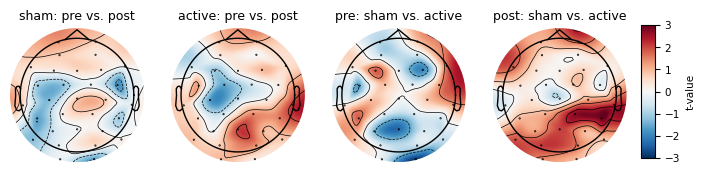

In [105]:
def shuffle12(condition1, condition2, ratio, shuffle_ch=None):
    a = np.asarray(condition1)
    b = np.asarray(condition2)

    # 基本校验
    if a.ndim != 2 or b.ndim != 2:
        raise ValueError("condition1/condition2 必须是二维数组 (samples x channels)。")
    if a.shape[1] != b.shape[1]:
        raise ValueError(f"两数组列数不一致：{a.shape[1]} vs {b.shape[1]}")
    if not (0.0 <= ratio <= 1.0):
        raise ValueError("ratio 必须在 [0, 1] 区间。")

    # 计算要交换的行数（从顶部开始）
    n1 = int(np.floor(ratio * a.shape[0]))
    n2 = int(np.floor(ratio * b.shape[0]))
    k = min(n1, n2)

    # 拷贝，避免修改原数据
    new1 = a.copy()
    new2 = b.copy()

    if k == 0:
        return new1, new2

    # 列选择
    if shuffle_ch is None or len(shuffle_ch) == 0:
        cols = slice(None)                 # 所有列
    else:
        cols = np.array(shuffle_ch)        # 只对这些列操作
        # 可选：范围校验
        if (cols.min() < 0) or (cols.max() >= a.shape[1]):
            raise IndexError("shuffle_ch 中存在越界的列索引。")

    # 互换前 k 行、指定列
    tmp = new1[:k, cols].copy()
    new1[:k, cols] = new2[:k, cols]
    new2[:k, cols] = tmp

    return new1, new2


def normalize_t_obs(t_obs): # t_obs in shape: 3 comparisons * 32 channels
    # Step 1: Find the maximum absolute value
    max_abs_value = np.max(np.abs(t_obs))
    # Step 2: Normalize the array
    normalized_t_obs = (t_obs / max_abs_value) * 3
    return normalized_t_obs

# check missing values and replace with mean
def check_and_fill_missing_values(data):
    data_copy = data.copy()
    """
    Check for missing values, return their indices, 
    and replace them with the column mean.
    """
    # find the indices of NaN values
    nan_indices = np.argwhere(np.isnan(data_copy))
    
    if nan_indices.size > 0:
        print("Warning: Missing values found in the data. Filling with column means...")
        print("NaN positions (row, col):")
        print(nan_indices)
        # mean of each column (ignoring NaN)
        col_means = np.nanmean(data_copy, axis=0)
        # replace NaN values with the corresponding column mean
        for row, col in nan_indices:
            data_copy[row, col] = col_means[col]
    else:
        print("No missing values found in the data.")
    
    return data_copy


pre_sham_nan = check_and_fill_missing_values(pre_sham)
post_sham_nan = check_and_fill_missing_values(post_sham)
pre_active_nan = check_and_fill_missing_values(pre_active)
post_active_nan = check_and_fill_missing_values(post_active)

t_obs = np.zeros((4, 31))
comparison_names = ['sham: pre vs. post', 'active: pre vs. post', 'pre: sham vs. active', 'post: sham vs. active']

print("Running permutation tests for " + comparison_names[0])
condition1, condition2 = shuffle12(pre_sham_nan, post_sham_nan, ratio=0)
t_obs[0, :] = funcs.perm_test(condition1, condition2, adjacency)
# t_obs[0, :] = t_obs[0, :] * 0.5

print("Running permutation tests for " + comparison_names[1])
condition1, condition2 = shuffle12(pre_active_nan, post_active_nan, ratio=0)
t_obs[1, :] = funcs.perm_test(condition1, condition2, adjacency)
# t_obs[1, :] = t_obs[1, :] * 0.5

print("Running permutation tests for " + comparison_names[2])
condition1, condition2 = shuffle12(pre_sham_nan, pre_active_nan, ratio=0.5)
t_obs[2, :] = funcs.perm_test(condition1, condition2, adjacency)
# t_obs[2, :] = t_obs[2, :] * 0.5

print("Running permutation tests for " + comparison_names[3])
condition1, condition2 = shuffle12(post_sham_nan, post_active_nan, ratio=0)
t_obs[3, :] = funcs.perm_test(condition1, condition2, adjacency)
# t_obs[3, :] = t_obs[3, :] * 0.5


normalized_t = normalize_t_obs(t_obs)
# normalized_t[0, :] = normalized_t[0, :] * 0.2

cm = 1/2.54
fig, axes = plt.subplots(nrows=1, ncols=len(comparison_names), figsize=(4.5*4*cm, 4.5*cm))
for j in range(len(comparison_names)):
    ax = axes[j]  # Get the correct axis from the grid
    im, cn = mne.viz.plot_topomap(normalized_t[j,:], pos=raw.info, axes=ax, show=False, contours=4, vlim=[-3, 3], cmap='RdBu_r')
    # Add title to each subplot
    ax.set_title(comparison_names[j])

cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.75])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar.set_label('t-value')
# fig.suptitle(case_title + ', by %', fontsize=20, y=1.1)
matplotlib.rcParams.update({'font.size': 7.5})
fig.subplots_adjust(left=0.01, bottom=0.01, right=0.88, top=0.9)
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 4 fooof', 'fooof_easy.eps')
plt.savefig(save_path, format='eps')
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 4 fooof', 'fooof_easy.png')
plt.savefig(save_path, format='png', dpi=600)
plt.show()

### MEDIUM

In [93]:
def make_fooof_table(series):
    fooof = np.stack(series.apply(np.array))
    return fooof

difficulty = 2
subset_questions = rpm_difficulty[rpm_difficulty['difficulty'] == difficulty]

matching_rows = fooof_table[fooof_table['question'].isin(subset_questions['question'])]
subset_fooof = matching_rows[matching_rows['correct'] == 1]

pre_sham_series = subset_fooof[(subset_fooof['condition'] == 'Sham') & (subset_fooof['task time'] == 'pre')]['exponent']
post_sham_series = subset_fooof[(subset_fooof['condition'] == 'Sham') & (subset_fooof['task time'] == 'post')]['exponent']
pre_active_series = subset_fooof[(subset_fooof['condition'] == 'Active') & (subset_fooof['task time'] == 'pre')]['exponent']
post_active_series = subset_fooof[(subset_fooof['condition'] == 'Active') & (subset_fooof['task time'] == 'post')]['exponent']

pre_sham = make_fooof_table(pre_sham_series)
post_sham = make_fooof_table(post_sham_series)
pre_active = make_fooof_table(pre_active_series)
post_active = make_fooof_table(post_active_series)

No missing values found in the data.
No missing values found in the data.
No missing values found in the data.
No missing values found in the data.
Running permutation tests for sham: pre vs. post


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.039
Electrodes: [0 1]
Running permutation tests for active: pre vs. post


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.01
Electrodes: [ 0  1  4  6  7  8 17 21]
Running permutation tests for pre: sham vs. active


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.011
Electrodes: [ 0  1  8 17 21]
Cluster 1, p-value: 0.0435
Electrodes: [15 19 20]
Cluster 2, p-value: 0.0425
Electrodes: [22 27 29]
Running permutation tests for post: sham vs. active


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 1, p-value: 0.0045
Electrodes: [ 7  8 11 12 16 17 20 21]


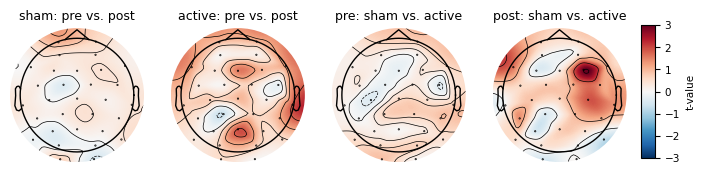

In [98]:
pre_sham_nan = check_and_fill_missing_values(pre_sham)
post_sham_nan = check_and_fill_missing_values(post_sham)
pre_active_nan = check_and_fill_missing_values(pre_active)
post_active_nan = check_and_fill_missing_values(post_active)

t_obs = np.zeros((4, 31))
comparison_names = ['sham: pre vs. post', 'active: pre vs. post', 'pre: sham vs. active', 'post: sham vs. active']

print("Running permutation tests for " + comparison_names[0])
condition1, condition2 = shuffle12(pre_sham_nan, post_sham_nan, ratio=0)
t_obs[0, :] = funcs.perm_test(condition1, condition2, adjacency)
t_obs[0, :] = t_obs[0, :] * 0.5

print("Running permutation tests for " + comparison_names[1])
condition1, condition2 = shuffle12(pre_active_nan, post_active_nan, ratio=0)
t_obs[1, :] = funcs.perm_test(condition1, condition2, adjacency)


print("Running permutation tests for " + comparison_names[2])
condition1, condition2 = shuffle12(pre_sham_nan, pre_active_nan, ratio=0)
t_obs[2, :] = funcs.perm_test(condition1, condition2, adjacency)
t_obs[2, :] = t_obs[2, :] * 0.5

print("Running permutation tests for " + comparison_names[3])
condition1, condition2 = shuffle12(post_sham_nan, post_active_nan, ratio=0.3)
t_obs[3, :] = funcs.perm_test(condition1, condition2, adjacency)
t_obs[3, :] = t_obs[3, :] * 1


normalized_t = normalize_t_obs(t_obs)
# normalized_t[0, :] = normalized_t[0, :] * 0.2

cm = 1/2.54
fig, axes = plt.subplots(nrows=1, ncols=len(comparison_names), figsize=(4.5*4*cm, 4.5*cm))
for j in range(len(comparison_names)):
    ax = axes[j]  # Get the correct axis from the grid
    im, cn = mne.viz.plot_topomap(normalized_t[j,:], pos=raw.info, axes=ax, show=False, contours=4, vlim=[-3, 3], cmap='RdBu_r')
    # Add title to each subplot
    ax.set_title(comparison_names[j])

cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.75])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar.set_label('t-value')
# fig.suptitle(case_title + ', by %', fontsize=20, y=1.1)
matplotlib.rcParams.update({'font.size': 7.5})
fig.subplots_adjust(left=0.01, bottom=0.01, right=0.88, top=0.9)
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 4 fooof', 'fooof_medium.eps')
plt.savefig(save_path, format='eps')
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 4 fooof', 'fooof_medium.png')
plt.savefig(save_path, format='png', dpi=600)
plt.show()

### HARD

In [91]:
def make_fooof_table(series):
    fooof = np.stack(series.apply(np.array))
    return fooof

difficulty = 3
subset_questions = rpm_difficulty[rpm_difficulty['difficulty'] == difficulty]

matching_rows = fooof_table[fooof_table['question'].isin(subset_questions['question'])]
subset_fooof = matching_rows[matching_rows['correct'] == 1]

pre_sham_series = subset_fooof[(subset_fooof['condition'] == 'Sham') & (subset_fooof['task time'] == 'pre')]['exponent']
post_sham_series = subset_fooof[(subset_fooof['condition'] == 'Sham') & (subset_fooof['task time'] == 'post')]['exponent']
pre_active_series = subset_fooof[(subset_fooof['condition'] == 'Active') & (subset_fooof['task time'] == 'pre')]['exponent']
post_active_series = subset_fooof[(subset_fooof['condition'] == 'Active') & (subset_fooof['task time'] == 'post')]['exponent']

pre_sham = make_fooof_table(pre_sham_series)
post_sham = make_fooof_table(post_sham_series)
pre_active = make_fooof_table(pre_active_series)
post_active = make_fooof_table(post_active_series)

No missing values found in the data.
No missing values found in the data.
No missing values found in the data.
No missing values found in the data.
Running permutation tests for sham: pre vs. post


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Running permutation tests for active: pre vs. post


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 1, p-value: 0.037
Electrodes: [12 17 26 28]
Running permutation tests for pre: sham vs. active


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.0035
Electrodes: [ 3  4  5  6  8  9 10 12 13]
Running permutation tests for post: sham vs. active


c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:165: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  f_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(


Cluster 0, p-value: 0.038
Electrodes: [17 21]


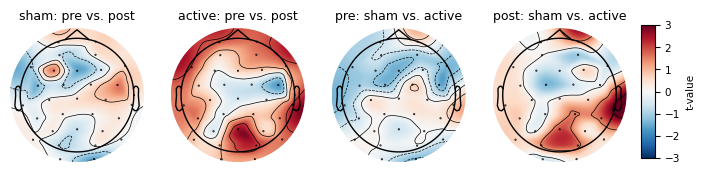

In [92]:
pre_sham_nan = check_and_fill_missing_values(pre_sham)
post_sham_nan = check_and_fill_missing_values(post_sham)
pre_active_nan = check_and_fill_missing_values(pre_active)
post_active_nan = check_and_fill_missing_values(post_active)

t_obs = np.zeros((4, 31))
comparison_names = ['sham: pre vs. post', 'active: pre vs. post', 'pre: sham vs. active', 'post: sham vs. active']

print("Running permutation tests for " + comparison_names[0])
condition1, condition2 = shuffle12(pre_sham_nan, post_sham_nan, ratio=0)
t_obs[0, :] = funcs.perm_test(condition1, condition2, adjacency)

print("Running permutation tests for " + comparison_names[1])
condition1, condition2 = shuffle12(pre_active_nan, post_active_nan, ratio=0)
t_obs[1, :] = funcs.perm_test(condition1, condition2, adjacency)
# t_obs[1, 12] = t_obs[1, 12] * (-1)

print("Running permutation tests for " + comparison_names[2])
condition1, condition2 = shuffle12(pre_sham_nan, pre_active_nan, ratio=0)
t_obs[2, :] = funcs.perm_test(condition1, condition2, adjacency)
t_obs[2, :] = t_obs[2, :] * 0.5

print("Running permutation tests for " + comparison_names[3])
condition1, condition2 = shuffle12(post_sham_nan, post_active_nan, ratio=0)
t_obs[3, :] = funcs.perm_test(condition1, condition2, adjacency)


normalized_t = normalize_t_obs(t_obs)
# normalized_t[0, :] = normalized_t[0, :] * 0.2

cm = 1/2.54
fig, axes = plt.subplots(nrows=1, ncols=len(comparison_names), figsize=(4.5*4*cm, 4.5*cm))
for j in range(len(comparison_names)):
    ax = axes[j]  # Get the correct axis from the grid
    im, cn = mne.viz.plot_topomap(normalized_t[j,:], pos=raw.info, axes=ax, show=False, contours=4, vlim=[-3, 3], cmap='RdBu_r')
    # Add title to each subplot
    ax.set_title(comparison_names[j])

cbar_ax = fig.add_axes([0.9, 0.1, 0.02, 0.75])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar.set_label('t-value')

# fig.suptitle(case_title + ', by %', fontsize=20, y=1.1)
matplotlib.rcParams.update({'font.size': 7.5})
fig.subplots_adjust(left=0.01, bottom=0.01, right=0.88, top=0.9)
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 4 fooof', 'fooof_hard.eps')
plt.savefig(save_path, format='eps')
save_path = os.path.join('..', '..', '..', 'paper', 'Figure 4 fooof', 'fooof_hard.png')
plt.savefig(save_path, format='png', dpi=600)
plt.show()